# Dem4Cli v2 development

1. New population data gridded - done > integrate into S2S
2. new masks for countries ? - coarsening to lower res - doing 
3. new cohort size data - done - check formatting / integrate for S2S
4. lookup table - add UNWPP life expectancy name column - done > do again but with original country mask column  


In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import pickle as pk
from scipy import interpolate
import glob, os, re, sys
import openpyxl
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 80)
%matplotlib inline 

sys.path.append('..')

from population_demographics_v2 import * 

## 1. load new cohort size data

### a) see old data

In [5]:
flags['version'] = 1
dir_cohortsizes = os.path.join(script_dir, 'data/cohort-sizes/WCDE/')
ssp=2

df_cohort_sizes, ages, years = load_cohort_sizes(dir_cohortsizes)


In [3]:
df_cohort_sizes

,2_1950,2_1955,2_1960,2_1965,2_1970,2_1975,2_1980,2_1985,2_1990,2_1995,...,102_2055,102_2060,102_2065,102_2070,102_2075,102_2080,102_2085,102_2090,102_2095,102_2100
Area,,,,,,,,,,,,,,,,,,,,,
Afghanistan,1291.6,1355.1,1539.5,1762.1,2025.6,2326.7,2484.4,2276.9,2377.9,3325.5,...,0.2,0.2,0.3,0.4,0.5,0.7,0.9,1.1,1.6,2.4
Albania,180.8,222.5,272.9,309.7,312.3,324.8,335.2,355.5,388.5,334.4,...,3.2,5.5,8.0,9.7,11.8,14.7,19.1,20.3,24.7,35.4
Algeria,1403.1,1830.6,2081.8,2398.0,2692.6,3086.2,3528.0,3893.8,3994.2,3734.3,...,15.7,23.0,35.4,52.8,78.8,123.7,179.8,235.8,281.4,297.1
Angola,739.2,1023.5,1095.3,1196.5,1298.7,1515.1,1810.3,2122.6,2438.5,2799.6,...,0.4,0.5,0.6,0.8,1.1,1.5,2.1,3.0,4.2,6.1
Antigua and Barbuda,6.6,8.4,8.9,9.2,9.9,9.3,7.3,7.2,7.4,6.8,...,0.0,0.1,0.1,0.1,0.1,0.1,0.2,0.2,0.3,0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Western Sahara,2.4,3.3,5.4,8.7,13.2,13.3,23.0,29.2,31.8,34.6,...,0.0,0.0,0.1,0.1,0.2,0.3,0.4,0.5,0.7,0.9
World,338387.2,405612.1,432642.8,480601.0,523700.8,543302.0,548178.6,592792.3,644867.3,623061.1,...,5799.9,7789.0,10822.7,14499.7,18443.9,22134.8,28115.2,36321.0,42244.2,48218.6
Yemen,770.2,777.9,860.3,978.0,1173.4,1348.4,1709.7,2115.3,2603.1,3082.0,...,0.3,0.4,0.5,0.7,1.1,2.1,3.4,5.2,7.8,10.2


In [6]:
filepath = dir_cohortsizes+f'wicdf_ssp{ssp}.csv'
df_raw = pd.read_csv(filepath, header=7) # population is in 000's

# total national population through time (rows = countries with names from WCDE, check they match, columns = years)
df_pop_national = df_raw[(df_raw['Sex'] == 'Both') & (df_raw['Age'] == 'All')][['Area', 'Year', 'Population']].pivot(index="Area", columns="Year", values="Population")


In [ ]:
df_raw # you want it to look like this!

,Area,Year,Age,Sex,ISOCode,Population
0,Afghanistan,1950,All,Both,4,7752.1
1,Afghanistan,1955,All,Both,4,8270.5
2,Afghanistan,1960,All,Both,4,8992.4
3,Afghanistan,1965,All,Both,4,9935.0
4,Afghanistan,1970,All,Both,4,11122.4
...,...,...,...,...,...,...
413287,Zimbabwe,2080,100+,Female,716,1.2
413288,Zimbabwe,2085,100+,Female,716,1.8
413289,Zimbabwe,2090,100+,Female,716,2.6
413290,Zimbabwe,2095,100+,Female,716,3.5


### b) new data

In [10]:
flags

{'version': 1, 'pop_resolution': 0.1, 'GMT_mapping': 'year_to_year'}

In [11]:
dir_cohortsizes

'/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/demographics4climate/data/cohort-sizes/WCDE_v3.2.beta'

In [12]:
filepath_cohortsizes=dir_cohortsizes+'/ssp_basic_drivers_release_3.2.beta_full.xlsx'

In [13]:
pd.read_excel(filepath_cohortsizes, sheet_name=1)

,Model,Scenario,Region,Variable,Unit,1950,1955,1960,1965,1970,...,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100
0,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Mean Years of Education|Female|Age 100+,years,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Mean Years of Education|Female|Age 15-19,years,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Mean Years of Education|Female|Age 20-24,years,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Mean Years of Education|Female|Age 25-29,years,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Mean Years of Education|Female|Age 30-34,years,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406882,OECD ENV-Growth 2025,SSP5,Zimbabwe,GDP|PPP,billion USD_2015/yr,NaN,NaN,NaN,NaN,NaN,...,167.817493,202.230159,242.446718,289.227372,344.150188,408.863839,484.958158,574.577244,679.527459,801.530437
406883,OECD ENV-Growth 2025,SSP5,Zimbabwe,GDP|PPP,billion USD_2017/yr,NaN,NaN,NaN,NaN,NaN,...,142.607000,171.850000,206.025000,245.778000,292.450000,347.442000,412.105000,488.261000,577.445000,681.120000
406884,OECD ENV-Growth 2025,SSP5,Zimbabwe,GDP|PPP [per capita],USD_2010/yr,NaN,NaN,NaN,NaN,NaN,...,7173.363687,8652.728869,10446.998134,12612.926499,15222.120997,18366.588436,22153.943502,26753.568238,32317.872273,39014.010438
406885,OECD ENV-Growth 2025,SSP5,Zimbabwe,GDP|PPP [per capita],USD_2015/yr,NaN,NaN,NaN,NaN,NaN,...,8073.332338,9738.298355,11757.676253,14195.341521,17131.884994,20670.856635,24933.372446,30110.065103,36372.465515,43908.699720


In [14]:

df = pd.read_excel(filepath_cohortsizes, sheet_name=1)

# 1. Exclude rows where 'region' contains (R<number>)
df = df[~df['Region'].str.contains(r"\(R\d+\)", regex=True, na=False)]

# 2. Keep only:
#    - Exactly "Population"
#    - Or "Population|Male|Age <age>"
#    - Or "Population|Female|Age <age>"
population_pattern = (
    #r"^Population$"  # exactly 'Population'
    r"^Population\|(Male|Female)\|Age\s(\d{1,2}(-\d{1,2})?|100\+)$" # age range
)

df = df[df['Variable'].str.contains(population_pattern, regex=True, na=False)]

In [16]:
df

,Model,Scenario,Region,Variable,Unit,1950,1955,1960,1965,1970,...,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100
38,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Population|Female|Age 0-4,million,0.630666,0.633850,0.713825,0.820112,0.949960,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Population|Female|Age 10-14,million,0.405776,0.443287,0.511051,0.525418,0.608655,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Population|Female|Age 100+,million,0.000000,0.000000,0.000000,0.000000,0.000001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Population|Female|Age 15-19,million,0.353874,0.386877,0.422271,0.493369,0.508750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Population|Female|Age 20-24,million,0.304909,0.332729,0.363826,0.402941,0.472583,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399088,IIASA-WiC POP 2025,SSP5,Zimbabwe,Population|Male|Age 75-79,million,NaN,NaN,NaN,NaN,NaN,...,0.143250,0.204322,0.211735,0.242217,0.319896,0.395627,0.438217,0.529094,0.565268,0.594757
399095,IIASA-WiC POP 2025,SSP5,Zimbabwe,Population|Male|Age 80-84,million,NaN,NaN,NaN,NaN,NaN,...,0.070287,0.106202,0.155388,0.165164,0.193778,0.263518,0.334017,0.378790,0.467772,0.510505
399102,IIASA-WiC POP 2025,SSP5,Zimbabwe,Population|Male|Age 85-89,million,NaN,NaN,NaN,NaN,NaN,...,0.026024,0.042097,0.065886,0.099905,0.110098,0.133990,0.190208,0.250217,0.294268,0.376550
399109,IIASA-WiC POP 2025,SSP5,Zimbabwe,Population|Male|Age 90-94,million,NaN,NaN,NaN,NaN,NaN,...,0.007523,0.011178,0.018921,0.031030,0.049368,0.057166,0.073223,0.110432,0.153345,0.190379


In [17]:
# Extract sex and age from Variable
df['sex'] = df['Variable'].str.extract(r"^Population\|(Male|Female)", expand=False)
df['age'] = df['Variable'].str.extract(r"Age\s([\d\+]+(?:-\d+)?)", expand=False)


In [18]:
# Melt year columns to long format
year_cols = [c for c in df.columns if re.match(r"^\d{4}$", str(c))]
df_long = df.melt(
    id_vars=['Region', 'sex', 'age','Scenario'],
    value_vars=year_cols,
    var_name='time',
    value_name='population'
)
df_long['time'] = df_long['time'].astype(int)
df_long['Scenario'] = df_long['Scenario'].replace({'Historical Reference': 'historical'})



In [19]:
df_long

,Region,sex,age,Scenario,time,population
0,Afghanistan,Female,0-4,historical,1950,0.630666
1,Afghanistan,Female,10-14,historical,1950,0.405776
2,Afghanistan,Female,100+,historical,1950,0.000000
3,Afghanistan,Female,15-19,historical,1950,0.353874
4,Afghanistan,Female,20-24,historical,1950,0.304909
...,...,...,...,...,...,...
1623589,Zimbabwe,Male,75-79,SSP5,2100,0.594757
1623590,Zimbabwe,Male,80-84,SSP5,2100,0.510505
1623591,Zimbabwe,Male,85-89,SSP5,2100,0.376550
1623592,Zimbabwe,Male,90-94,SSP5,2100,0.190379


In [20]:
df_long.set_index(['Region', 'time', 'age', 'sex','Scenario'])

population
Region      time age   sex    Scenario              
Afghanistan 1950 0-4   Female historical    0.630666
                 10-14 Female historical    0.405776
                 100+  Female historical    0.000000
                 15-19 Female historical    0.353874
                 20-24 Female historical    0.304909
...                                              ...
Zimbabwe    2100 75-79 Male   SSP5          0.594757
                 80-84 Male   SSP5          0.510505
                 85-89 Male   SSP5          0.376550
                 90-94 Male   SSP5          0.190379
                 95-99 Male   SSP5          0.069001

[1623594 rows x 1 columns]

In [37]:
df_long['age'] = df_long['age'].apply(convert_age_range) + 2 

In [38]:
da = df_long.set_index(['Region', 'time', 'age', 'sex', 'Scenario']).to_xarray()['population']
da

<xarray.DataArray 'population' (Region: 237, time: 31, age: 21, sex: 2,
                                Scenario: 6)>
array([[[[[         nan,          nan,          nan,          nan,
                    nan, 6.306660e-01],
          [         nan,          nan,          nan,          nan,
                    nan, 6.189320e-01]],

         [[         nan,          nan,          nan,          nan,
                    nan, 4.627210e-01],
          [         nan,          nan,          nan,          nan,
                    nan, 4.912800e-01]],

         [[         nan,          nan,          nan,          nan,
                    nan, 4.057760e-01],
          [         nan,          nan,          nan,          nan,
                    nan, 4.422050e-01]],

         ...,

         [[         nan,          nan,          nan,          nan,
                    nan, 5.500000e-05],
          [         nan,          nan,          nan,          nan,
...
           3.023700e-01,          nan],
          [3.556150e-01, 6.956870e-01, 1.216286e+00, 1.109081e+00,
           3.102040e-01,          nan]],

         ...,

         [[4.044000e-01, 8.770100e-02, 4.394000e-02, 4.172300e-02,
           3.561450e-01,          nan],
          [2.321220e-01, 4.419300e-02, 1.674300e-02, 1.529800e-02,
           1.903790e-01,          nan]],

         [[1.947570e-01, 2.326400e-02, 1.104300e-02, 1.061500e-02,
           1.742830e-01,          nan],
          [8.197700e-02, 8.876000e-03, 3.021000e-03, 2.806000e-03,
           6.900100e-02,          nan]],

         [[4.961000e-02, 3.116000e-03, 1.506000e-03, 1.463000e-03,
           4.537400e-02,          nan],
          [1.330400e-02, 8.440000e-04, 2.790000e-04, 2.640000e-04,
           1.161900e-02,          nan]]]]])
Coordinates:
  * Region    (Region) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time      (time) int64 1950 1955 1960 1965 1970 ... 2080 2085 2090 2095 2100
  * age       (age) int64 2 7 12 17 22 27 32 37 42 ... 67 72 77 82 87 92 97 102
  * sex       (sex) object 'Female' 'Male'
  * Scenario  (Scenario) object 'SSP1' 'SSP2' 'SSP3' 'SSP4' 'SSP5' 'historical'

In [39]:
da.age

<xarray.DataArray 'age' (age: 21)>
array([  2,   7,  12,  17,  22,  27,  32,  37,  42,  47,  52,  57,  62,  67,
        72,  77,  82,  87,  92,  97, 102])
Coordinates:
  * age      (age) int64 2 7 12 17 22 27 32 37 42 ... 67 72 77 82 87 92 97 102

In [22]:
da = da.rename({'Region':'country', 'Scenario':'ssp'})
da

<xarray.DataArray 'population' (country: 237, time: 31, age: 21, sex: 2, ssp: 6)>
array([[[[[         nan,          nan,          nan,          nan,
                    nan, 6.306660e-01],
          [         nan,          nan,          nan,          nan,
                    nan, 6.189320e-01]],

         [[         nan,          nan,          nan,          nan,
                    nan, 4.057760e-01],
          [         nan,          nan,          nan,          nan,
                    nan, 4.422050e-01]],

         [[         nan,          nan,          nan,          nan,
                    nan, 0.000000e+00],
          [         nan,          nan,          nan,          nan,
                    nan, 0.000000e+00]],

         ...,

         [[         nan,          nan,          nan,          nan,
                    nan, 5.470000e-04],
          [         nan,          nan,          nan,          nan,
...
           4.537400e-02,          nan],
          [1.330400e-02, 8.440000e-04, 2.790000e-04, 2.640000e-04,
           1.161900e-02,          nan]],

         ...,

         [[6.621990e-01, 2.322970e-01, 1.273710e-01, 1.195540e-01,
           5.748720e-01,          nan],
          [4.689500e-01, 1.444020e-01, 6.366200e-02, 5.725400e-02,
           3.765500e-01,          nan]],

         [[4.044000e-01, 8.770100e-02, 4.394000e-02, 4.172300e-02,
           3.561450e-01,          nan],
          [2.321220e-01, 4.419300e-02, 1.674300e-02, 1.529800e-02,
           1.903790e-01,          nan]],

         [[1.947570e-01, 2.326400e-02, 1.104300e-02, 1.061500e-02,
           1.742830e-01,          nan],
          [8.197700e-02, 8.876000e-03, 3.021000e-03, 2.806000e-03,
           6.900100e-02,          nan]]]]])
Coordinates:
  * country  (country) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time     (time) int64 1950 1955 1960 1965 1970 ... 2080 2085 2090 2095 2100
  * age      (age) object '0-4' '10-14' '100+' ... '85-89' '90-94' '95-99'
  * sex      (sex) object 'Female' 'Male'
  * ssp      (ssp) object 'SSP1' 'SSP2' 'SSP3' 'SSP4' 'SSP5' 'historical'

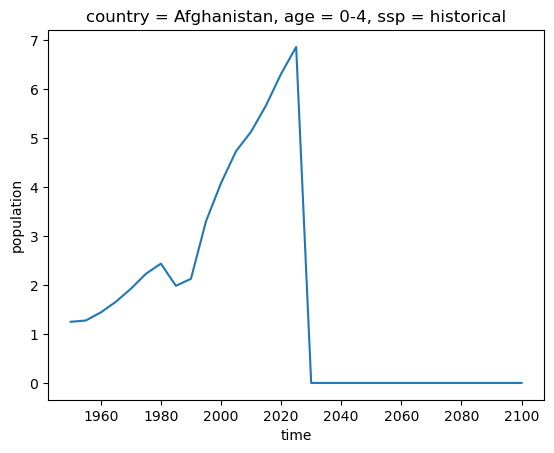

In [23]:
da.sel(ssp='historical', country='Afghanistan',age='0-4').sum(dim='sex').plot()

### test fxn

In [2]:
flags

{'version': 2, 'pop_resolution': 0.1, 'GMT_mapping': 'year_to_year'}

In [3]:
dir_cohortsizes

'/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/demographics4climate/data/cohort-sizes/WCDE_v3.2.beta'

In [4]:
df_cohort_sizes, ages, years = load_cohort_sizes()

In [5]:
df_cohort_sizes

<xarray.DataArray 'population' (country: 237, time: 31, age: 21)>
array([[[1.249598e+00, 9.540010e-01, 8.479810e-01, ..., 1.270000e-04,
         5.000000e-06, 0.000000e+00],
        [1.275876e+00, 1.062110e+00, 9.167520e-01, ..., 1.880000e-04,
         1.000000e-05, 0.000000e+00],
        [1.440271e+00, 1.093636e+00, 1.018713e+00, ..., 3.030000e-04,
         1.700000e-05, 0.000000e+00],
        ...,
        [6.332444e+00, 6.562508e+00, 6.998489e+00, ..., 1.450260e-01,
         2.017500e-02, 1.347000e-03],
        [6.170132e+00, 6.334755e+00, 6.561198e+00, ..., 1.840270e-01,
         2.751600e-02, 1.974000e-03],
        [5.976391e+00, 6.176918e+00, 6.337566e+00, ..., 2.249140e-01,
         3.629300e-02, 2.799000e-03]],

       [[1.839550e-01, 1.559470e-01, 1.424010e-01, ..., 9.080000e-04,
         1.500000e-04, 1.600000e-05],
        [2.309190e-01, 1.743350e-01, 1.537790e-01, ..., 1.680000e-03,
         2.800000e-04, 2.600000e-05],
        [2.890380e-01, 2.228960e-01, 1.746340e-01, ..., 3.002000e-03,
         4.410000e-04, 5.000000e-05],
...
        [2.758125e+00, 2.816799e+00, 2.908411e+00, ..., 7.242500e-02,
         1.265800e-02, 1.233000e-03],
        [2.671221e+00, 2.745646e+00, 2.811111e+00, ..., 9.179400e-02,
         1.618600e-02, 1.592000e-03],
        [2.585075e+00, 2.660460e+00, 2.740787e+00, ..., 1.190690e-01,
         2.111000e-02, 2.100000e-03]],

       [[4.761510e-01, 3.828150e-01, 3.160930e-01, ..., 3.470000e-04,
         5.200000e-05, 4.000000e-06],
        [6.402860e-01, 4.421300e-01, 3.746380e-01, ..., 4.350000e-04,
         5.900000e-05, 3.000000e-06],
        [7.324900e-01, 6.007910e-01, 4.334990e-01, ..., 4.870000e-04,
         7.400000e-05, 5.000000e-06],
        ...,
        [1.386299e+00, 1.451760e+00, 1.494274e+00, ..., 8.475600e-02,
         1.724800e-02, 2.347000e-03],
        [1.328739e+00, 1.379947e+00, 1.449082e+00, ..., 1.114820e-01,
         2.372400e-02, 2.795000e-03],
        [1.271387e+00, 1.324858e+00, 1.379785e+00, ..., 1.318940e-01,
         3.214000e-02, 3.960000e-03]]])
Coordinates:
  * country  (country) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time     (time) int64 1950 1955 1960 1965 1970 ... 2080 2085 2090 2095 2100
  * age      (age) int64 2 7 12 17 22 27 32 37 42 ... 67 72 77 82 87 92 97 102

In [6]:
ages

array([  2,   7,  12,  17,  22,  27,  32,  37,  42,  47,  52,  57,  62,
        67,  72,  77,  82,  87,  92,  97, 102])

In [7]:
years

array([1950, 1955, 1960, 1965, 1970, 1975, 1980, 1985, 1990, 1995, 2000,
       2005, 2010, 2015, 2020, 2025, 2030, 2035, 2040, 2045, 2050, 2055,
       2060, 2065, 2070, 2075, 2080, 2085, 2090, 2095, 2100])

In [8]:
da = df_cohort_sizes

In [11]:
da.sel(country='Afghanistan').to_pandas().T

time,1950,1955,1960,1965,1970,1975,1980,1985,1990,1995,...,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100
age,,,,,,,,,,,,,,,,,,,,,
2,1.249598,1.275876,1.440271,1.657766,1.923350,2.229691,2.438529,1.984951,2.128086,3.302788,...,8.217687,8.136818,8.005578,7.744366,7.451600,7.018162,6.565949,6.332444,6.170132,5.976391
7,0.954001,1.062110,1.093636,1.266617,1.476636,1.725049,1.905433,1.590426,1.622083,2.480957,...,8.167990,8.161414,8.088521,7.965643,7.714048,7.430467,7.006311,6.562508,6.334755,6.176918
12,0.847981,0.916752,1.018713,1.062485,1.233340,1.433583,1.582033,1.335124,1.390359,1.984530,...,8.033591,8.128721,8.125283,8.056585,7.938613,7.693243,7.415788,6.998489,6.561198,6.337566
17,0.751730,0.811910,0.876395,0.986516,1.031631,1.194216,1.310253,1.102901,1.166653,1.697424,...,7.804234,7.978761,8.081695,8.087336,8.028349,7.920280,7.685320,7.417550,7.009684,6.580692
22,0.663389,0.708569,0.765037,0.837726,0.946259,0.987882,1.078048,0.892458,0.943803,1.405261,...,7.442725,7.686698,7.864888,7.973113,7.985126,7.934032,7.834237,7.609435,7.351711,6.955146
27,0.568208,0.617233,0.659798,0.723487,0.795823,0.898145,0.883705,0.724457,0.751537,1.126579,...,6.966567,7.308440,7.555248,7.738782,7.853007,7.872464,7.829989,7.739729,7.526605,7.280564
32,0.487298,0.524196,0.570358,0.619671,0.683032,0.751196,0.799741,0.590222,0.608275,0.895322,...,6.367926,6.848340,7.190753,7.441175,7.630061,7.750914,7.777355,7.743173,7.661719,7.459397
37,0.416301,0.444182,0.479103,0.530351,0.579707,0.639376,0.664331,0.530935,0.493473,0.722408,...,5.756779,6.259134,6.737051,7.080722,7.334753,7.529362,7.656542,7.690001,7.663524,7.590224
42,0.353457,0.374167,0.400737,0.440224,0.490679,0.537164,0.559966,0.438479,0.440306,0.583378,...,5.031359,5.649756,6.146863,6.622754,6.967986,7.226474,7.427083,7.561322,7.602230,7.583917


## 1b. interpolate this new data

In [9]:
# test fxn 


da_cohort_size = interpolate_cohortsize_countries(df_cohort_sizes, ages, years)

interpolating cohort sizes per country
after interpolation and mean-preserving correction there are some neg numbers in 6, Anguilla, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 15, Bahrain, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 29, British Virgin Islands, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 32, Burkina Faso, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 39, Central African Republic, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 61, El Salvador, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 65, Eswatini, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 68, Faroe Islands, setting them t

## 2. Load new population data

In [2]:
flags

{'version': 2, 'pop_resolution': 0.1, 'GMT_mapping': 'year_to_year'}

In [3]:
dir_population

'/data/brussel/vo/000/bvo00012/data/dataset/COMPASS/v2/population_count/01deg'

In [49]:
da_population = load_population()

opening compass - historical
opening compass - ssp2


In [5]:
da_population

<xarray.DataArray 'Population_count' (time: 151, lat: 1800, lon: 3600)>
dask.array<concatenate, shape=(151, 1800, 3600), dtype=float32, chunksize=(1, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -179.9 -179.8 -179.8 -179.7 ... 179.7 179.8 179.9
  * lat      (lat) float64 -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2096 2097 2098 2099 2100
Attributes:
    units:      1
    long_name:  Population_count

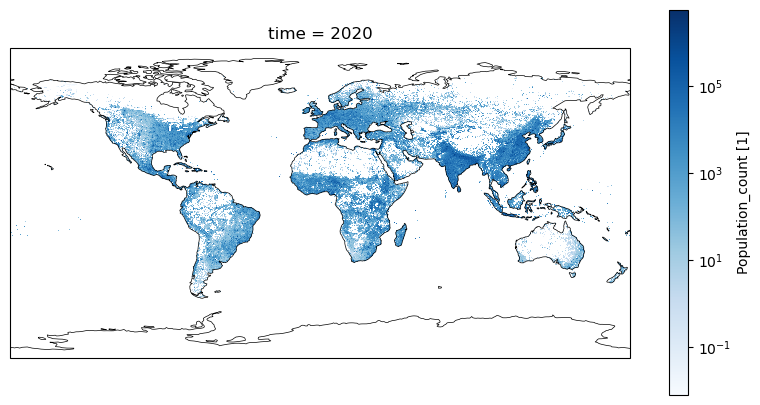

In [8]:
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature



da = da_population.sel(time=2020)

fig, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    figsize=(10, 5)
)

da.where(da>.000001).plot(norm=LogNorm(), cmap='Blues', ax=ax)

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)


In [9]:
da_population

<xarray.DataArray 'Population_count' (time: 151, lat: 1800, lon: 3600)>
dask.array<concatenate, shape=(151, 1800, 3600), dtype=float32, chunksize=(1, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -179.9 -179.8 -179.8 -179.7 ... 179.7 179.8 179.9
  * lat      (lat) float64 -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2096 2097 2098 2099 2100
Attributes:
    units:      1
    long_name:  Population_count

In [24]:
# test the bbox - ok works! 


da_population_portugal = load_population(
    dir_population= dir_population, 
    startyear=1950,
    endyear=2100,
    ssp=2,
    urbanrural=False,
    chunksize=100,
    bbox = [32.75, 42.25,  -28.75, -6.25]

)

opening compass - historical
opening compass - ssp2


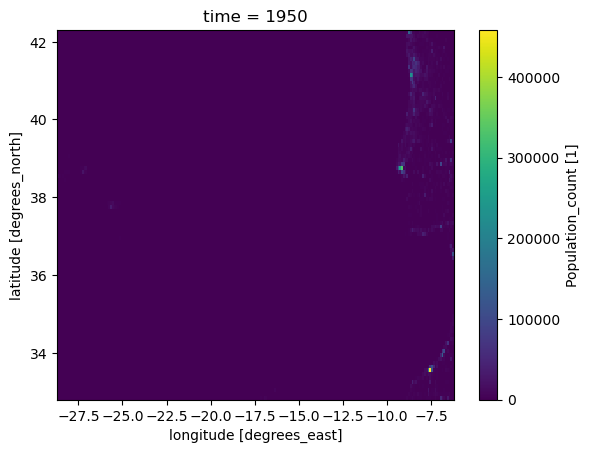

In [25]:
da_population_portugal.isel(time=0).plot()

In [10]:
#testing old version still works 


# flags['version']=1
# dir_population = os.path.join(script_dir, 'data/gridded-pop/') 
# da_population = load_population(dir_population)

In [11]:
# da_population

## 4. new lookup table? 

Masks - cohort data (SSP) already matched - but im not using this !

To do: 
- match life expectancy data name 
    - Just match based on SDMX code = ISO numeric! This is available in UNWPP2024 data! ?? > make this index in da_cohorts? or add column here to the lookup table with the names in UNWPP ! 
    - Done, as 'WPP name' 
- Add the original country mask name from ISIPEDIA as well ! Based on ISO-3 check overlap 
- Check overlap also with SSP cohort size projections
    - ok, correct but 35 countries dont have cohort size projections - decide what to do about this / how much does it matter? 

### check it 

In [5]:
df_lookuptable = pd.read_excel(filepath_lookuptable_original)

In [6]:
df_lookuptable

,SSP name,ISO name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill
0,Afghanistan,Afghanistan,AF,AFG,4,Full historical + SSP,NaN
1,Albania,Albania,AL,ALB,8,Full historical + SSP,NaN
2,Algeria,Algeria,DZ,DZA,12,Full historical + SSP,NaN
3,Angola,Angola,AO,AGO,24,Full historical + SSP,NaN
4,Antigua and Barbuda,Antigua and Barbuda,AG,ATG,28,Full historical + SSP,NaN
...,...,...,...,...,...,...,...
244,NaN,Norfolk Island,NF,NFK,574,No data,Rest of Asia (R10)
245,NaN,Pitcairn,PN,PCN,612,No data,Rest of Asia (R10)
246,NaN,South Georgia and the South Sandwich Islands,GS,SGS,239,No population,NaN
247,NaN,Svalbard and Jan Mayen,SJ,SJM,744,No data,Europe (R10)


In [8]:
filepath_lifeexpectancy = os.path.join(data_dir, 'life-expectancy/UN_WPP2024/WPP2024_MORT_F05_1_LIFE_EXPECTANCY_BY_AGE_BOTH_SEXES.xlsx')

df_unwpp_raw = pd.read_excel(filepath_lifeexpectancy, 
             sheet_name=0,
             skiprows=16)

In [22]:
df_unwpp = df_unwpp_raw[df_unwpp_raw['Type']=='Country/Area'].rename(
              columns={'Region, subregion, country or area *':'WPP name', 'SDMX code**':'ISO numeric'}) # make this more flex 
cols = df_unwpp.columns
idxs = [i for i, col in enumerate(cols) if col in ('WPP name', 'ISO numeric')] #  'ISO3 Alpha-code'
df_unwpp = df_unwpp.iloc[:, idxs].drop_duplicates()
df_unwpp['ISO numeric'] = df_unwpp['ISO numeric'].astype(int)

df_unwpp

,WPP name,ISO numeric
2594,Burundi,108
2668,Comoros,174
2742,Djibouti,262
2816,Eritrea,232
2890,Ethiopia,231
...,...,...
21686,Samoa,882
21760,Tokelau,772
21834,Tonga,776
21908,Tuvalu,798


In [41]:
cols = df_lookuptable.columns.values
new_cols = list(cols[:2]) + ['WPP name'] + list(cols[2:])
new_cols
df_lookuptable_new = df_lookuptable.merge(df_unwpp, how='outer', on='ISO numeric').loc[:, new_cols]

In [42]:
diff_mask = df_lookuptable_new['SSP name'] != df_lookuptable_new['WPP name']
df_differences = df_lookuptable_new[diff_mask][['ISO numeric', 'SSP name', 'WPP name']]
df_differences

,ISO numeric,SSP name,WPP name
20,68,Bolivia,Bolivia (Plurinational State of)
78,344,Hong Kong,"China, Hong Kong SAR"
83,364,Iran,Iran (Islamic Republic of)
94,412,Kosovo,Kosovo (under UNSC res. 1244)
97,418,Laos,Lao People's Democratic Republic
105,446,Macao,"China, Macao SAR"
117,583,Micronesia,Micronesia (Fed. States of)
118,498,Moldova,Republic of Moldova
132,408,North Korea,Dem. People's Republic of Korea
137,275,Palestine,State of Palestine


In [ ]:
#df_lookuptable_new.to_csv('../data/country-masks/lookup_table_dem4cli_v2.csv', index=False)

### add ISO3 to dataframe

In [3]:
df_lookuptable = pd.read_csv(filepath_lookuptable) # new one

In [4]:
df_lookuptable

,SSP name,ISO name,WPP name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill
0,Afghanistan,Afghanistan,Afghanistan,AF,AFG,4,Full historical + SSP,NaN
1,Albania,Albania,Albania,AL,ALB,8,Full historical + SSP,NaN
2,Algeria,Algeria,Algeria,DZ,DZA,12,Full historical + SSP,NaN
3,Angola,Angola,Angola,AO,AGO,24,Full historical + SSP,NaN
4,Antigua and Barbuda,Antigua and Barbuda,Antigua and Barbuda,AG,ATG,28,Full historical + SSP,NaN
...,...,...,...,...,...,...,...,...
244,NaN,Norfolk Island,NaN,NF,NFK,574,No data,Rest of Asia (R10)
245,NaN,Pitcairn,NaN,PN,PCN,612,No data,Rest of Asia (R10)
246,NaN,South Georgia and the South Sandwich Islands,NaN,GS,SGS,239,No population,NaN
247,NaN,Svalbard and Jan Mayen,NaN,SJ,SJM,744,No data,Europe (R10)


In [5]:
# add/check countrymask availability info 
da_countrymasks = load_countrymasks_fillcoasts(
    filepath_countrymask=filepath_countrymask,
    fillcoast=False,
    fix_smallislands=False, # fix this for flexible resolution! 
    bbox=None,)


In [6]:
da_countrymasks

<xarray.DataArray (country: 225, lat: 1800, lon: 3600)>
dask.array<getitem, shape=(225, 1800, 3600), dtype=float32, chunksize=(1, 100, 100), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -179.9 -179.8 -179.8 -179.6 ... 179.8 179.9 180.0
  * lat      (lat) float64 -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
  * country  (country) <U5 'AFG' 'AGO' 'ALB' 'AND' ... 'YEM' 'ZAF' 'ZMB' 'ZWE'
Attributes:
    CDI:          Climate Data Interface version 2.4.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    source:       ASAP-GAUL, Natural Earth 10m v5.0.1
    repository:   https://github.com/ISI-MIP/isipedia-countries
    version:      v2.6
    note:         Fractional mask
    history:      Fri Sep 05 13:43:19 2025: cdo remapcon,grid_pop_01deg.txt t...
    CDO:          Climate Data Operators version 2.4.4 (https://mpimet.mpg.de...

In [9]:
pd.DataFrame(da_countrymasks.country.to_pandas())

,0
country,
AFG,AFG
AGO,AGO
ALB,ALB
AND,AND
ARE,ARE
...,...
WSM,WSM
YEM,YEM
ZAF,ZAF


In [10]:
df = df_lookuptable.merge(pd.DataFrame(da_countrymasks.country.to_pandas()), how='outer', left_on='ISO alpha-3', right_on='country')

In [19]:
df

,SSP name,ISO name,WPP name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill,0
0,Afghanistan,Afghanistan,Afghanistan,AF,AFG,4.0,Full historical + SSP,NaN,AFG
1,Albania,Albania,Albania,AL,ALB,8.0,Full historical + SSP,NaN,ALB
2,Algeria,Algeria,Algeria,DZ,DZA,12.0,Full historical + SSP,NaN,DZA
3,Angola,Angola,Angola,AO,AGO,24.0,Full historical + SSP,NaN,AGO
4,Antigua and Barbuda,Antigua and Barbuda,Antigua and Barbuda,AG,ATG,28.0,Full historical + SSP,NaN,ATG
...,...,...,...,...,...,...,...,...,...
247,NaN,Svalbard and Jan Mayen,NaN,SJ,SJM,744.0,No data,Europe (R10),SJM
248,NaN,United States Minor Outlying Islands,NaN,UM,UMI,581.0,No population,NaN,NaN
249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CSID
250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IOSID


In [20]:
252 - 30 +3 

225

In [15]:
df[df["ISO alpha-3"] != df[0]].reset_index()

,index,SSP name,ISO name,WPP name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill,0
0,7,Aruba,Aruba,Aruba,AW,ABW,533.0,Full historical + SSP,NaN,NaN
1,94,Kosovo,Kosovo,Kosovo (under UNSC res. 1244),XK,XKX,412.0,Full historical + SSP,NaN,NaN
2,105,Macao,Macao,"China, Macao SAR",MO,MAC,446.0,Full historical + SSP,NaN,NaN
3,203,Anguilla,Anguilla,Anguilla,AI,AIA,660.0,Only historical until 2015,Latin America (R10),NaN
4,205,"Bonaire, Sint Eustatius and Saba","Bonaire, Sint Eustatius and Saba","Bonaire, Sint Eustatius and Saba",BQ,BES,535.0,Only historical until 2015,Latin America (R10),NaN
5,208,Cook Islands,Cook Islands,Cook Islands,CK,COK,184.0,Only historical until 2015,Rest of Asia (R10),NaN
6,212,Gibraltar,Gibraltar,Gibraltar,GI,GIB,292.0,Only historical until 2015,Europe (R10),NaN
7,214,Guernsey,Guernsey,Guernsey,GG,GGY,831.0,Only historical until 2015,Europe (R10),NaN
8,216,Jersey,Jersey,Jersey,JE,JEY,832.0,Only historical until 2015,Europe (R10),NaN
9,217,Liechtenstein,Liechtenstein,Liechtenstein,LI,LIE,438.0,Only historical until 2015,Europe (R10),NaN


In [25]:
df['WPP name'][df['WPP name'].notna()].reset_index()

,index,WPP name
0,0,Afghanistan
1,1,Albania
2,2,Algeria
3,3,Angola
4,4,Antigua and Barbuda
...,...,...
232,232,Tokelau
233,233,Turks and Caicos Islands
234,234,Tuvalu
235,235,Wallis and Futuna Islands


In [26]:
df['SSP name'][df['SSP name'].notna()].reset_index()

,index,SSP name
0,0,Afghanistan
1,1,Albania
2,2,Algeria
3,3,Angola
4,4,Antigua and Barbuda
...,...,...
231,231,Sint Maarten (Dutch part)
232,232,Tokelau
233,233,Turks and Caicos Islands
234,234,Tuvalu


In [31]:
df[df[["SSP name", "WPP name", 0]].notna().all(axis=1)].reset_index().tail(40)

,index,SSP name,ISO name,WPP name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill,0
178,181,Tonga,Tonga,Tonga,TO,TON,776.0,Full historical + SSP,NaN,TON
179,182,Trinidad and Tobago,Trinidad and Tobago,Trinidad and Tobago,TT,TTO,780.0,Full historical + SSP,NaN,TTO
180,183,Tunisia,Tunisia,Tunisia,TN,TUN,788.0,Full historical + SSP,NaN,TUN
181,184,Turkey,Turkey,Türkiye,TR,TUR,792.0,Full historical + SSP,NaN,TUR
182,185,Turkmenistan,Turkmenistan,Turkmenistan,TM,TKM,795.0,Full historical + SSP,NaN,TKM
183,186,Uganda,Uganda,Uganda,UG,UGA,800.0,Full historical + SSP,NaN,UGA
184,187,Ukraine,Ukraine,Ukraine,UA,UKR,804.0,Full historical + SSP,NaN,UKR
185,188,United Arab Emirates,United Arab Emirates,United Arab Emirates,AE,ARE,784.0,Full historical + SSP,NaN,ARE
186,189,United Kingdom,United Kingdom of Great Britain and Northern I...,United Kingdom,GB,GBR,826.0,Full historical + SSP,NaN,GBR
187,190,United States,United States of America,United States of America,US,USA,840.0,Full historical + SSP,NaN,USA


In [29]:
df[df[["SSP name", "WPP name", 0]].isna().any(axis=1)].reset_index()

,index,SSP name,ISO name,WPP name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill,0
0,7,Aruba,Aruba,Aruba,AW,ABW,533.0,Full historical + SSP,NaN,NaN
1,94,Kosovo,Kosovo,Kosovo (under UNSC res. 1244),XK,XKX,412.0,Full historical + SSP,NaN,NaN
2,105,Macao,Macao,"China, Macao SAR",MO,MAC,446.0,Full historical + SSP,NaN,NaN
3,203,Anguilla,Anguilla,Anguilla,AI,AIA,660.0,Only historical until 2015,Latin America (R10),NaN
4,205,"Bonaire, Sint Eustatius and Saba","Bonaire, Sint Eustatius and Saba","Bonaire, Sint Eustatius and Saba",BQ,BES,535.0,Only historical until 2015,Latin America (R10),NaN
5,208,Cook Islands,Cook Islands,Cook Islands,CK,COK,184.0,Only historical until 2015,Rest of Asia (R10),NaN
6,212,Gibraltar,Gibraltar,Gibraltar,GI,GIB,292.0,Only historical until 2015,Europe (R10),NaN
7,214,Guernsey,Guernsey,Guernsey,GG,GGY,831.0,Only historical until 2015,Europe (R10),NaN
8,216,Jersey,Jersey,Jersey,JE,JEY,832.0,Only historical until 2015,Europe (R10),NaN
9,217,Liechtenstein,Liechtenstein,Liechtenstein,LI,LIE,438.0,Only historical until 2015,Europe (R10),NaN


### Check overlap with SSP projs

yes all good - Dominik seems mapped correctly! 

But check there are 35 countries with projections missing that are in cohsize! remove them? does it matter?

In [32]:
df_cohort_sizes, ages, years = load_cohort_sizes(dir_cohortsizes, ssp=2, by_sex=False)
df_cohort_sizes

<xarray.DataArray 'population' (country: 237, time: 31, age: 21)>
array([[[1.249598e+00, 9.540010e-01, 8.479810e-01, ..., 1.270000e-04,
         5.000000e-06, 0.000000e+00],
        [1.275876e+00, 1.062110e+00, 9.167520e-01, ..., 1.880000e-04,
         1.000000e-05, 0.000000e+00],
        [1.440271e+00, 1.093636e+00, 1.018713e+00, ..., 3.030000e-04,
         1.700000e-05, 0.000000e+00],
        ...,
        [6.332444e+00, 6.562508e+00, 6.998489e+00, ..., 1.450260e-01,
         2.017500e-02, 1.347000e-03],
        [6.170132e+00, 6.334755e+00, 6.561198e+00, ..., 1.840270e-01,
         2.751600e-02, 1.974000e-03],
        [5.976391e+00, 6.176918e+00, 6.337566e+00, ..., 2.249140e-01,
         3.629300e-02, 2.799000e-03]],

       [[1.839550e-01, 1.559470e-01, 1.424010e-01, ..., 9.080000e-04,
         1.500000e-04, 1.600000e-05],
        [2.309190e-01, 1.743350e-01, 1.537790e-01, ..., 1.680000e-03,
         2.800000e-04, 2.600000e-05],
        [2.890380e-01, 2.228960e-01, 1.746340e-01, ..., 3.002000e-03,
         4.410000e-04, 5.000000e-05],
...
        [2.758125e+00, 2.816799e+00, 2.908411e+00, ..., 7.242500e-02,
         1.265800e-02, 1.233000e-03],
        [2.671221e+00, 2.745646e+00, 2.811111e+00, ..., 9.179400e-02,
         1.618600e-02, 1.592000e-03],
        [2.585075e+00, 2.660460e+00, 2.740787e+00, ..., 1.190690e-01,
         2.111000e-02, 2.100000e-03]],

       [[4.761510e-01, 3.828150e-01, 3.160930e-01, ..., 3.470000e-04,
         5.200000e-05, 4.000000e-06],
        [6.402860e-01, 4.421300e-01, 3.746380e-01, ..., 4.350000e-04,
         5.900000e-05, 3.000000e-06],
        [7.324900e-01, 6.007910e-01, 4.334990e-01, ..., 4.870000e-04,
         7.400000e-05, 5.000000e-06],
        ...,
        [1.386299e+00, 1.451760e+00, 1.494274e+00, ..., 8.475600e-02,
         1.724800e-02, 2.347000e-03],
        [1.328739e+00, 1.379947e+00, 1.449082e+00, ..., 1.114820e-01,
         2.372400e-02, 2.795000e-03],
        [1.271387e+00, 1.324858e+00, 1.379785e+00, ..., 1.318940e-01,
         3.214000e-02, 3.960000e-03]]])
Coordinates:
  * country  (country) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time     (time) int64 1950 1955 1960 1965 1970 ... 2080 2085 2090 2095 2100
  * age      (age) int64 2 7 12 17 22 27 32 37 42 ... 67 72 77 82 87 92 97 102

In [ ]:
df_cohort_sizes.sel(country != 'World')

<xarray.DataArray 'population' (country: 237, time: 31, age: 21)>
array([[[1.249598e+00, 9.540010e-01, 8.479810e-01, ..., 1.270000e-04,
         5.000000e-06, 0.000000e+00],
        [1.275876e+00, 1.062110e+00, 9.167520e-01, ..., 1.880000e-04,
         1.000000e-05, 0.000000e+00],
        [1.440271e+00, 1.093636e+00, 1.018713e+00, ..., 3.030000e-04,
         1.700000e-05, 0.000000e+00],
        ...,
        [6.332444e+00, 6.562508e+00, 6.998489e+00, ..., 1.450260e-01,
         2.017500e-02, 1.347000e-03],
        [6.170132e+00, 6.334755e+00, 6.561198e+00, ..., 1.840270e-01,
         2.751600e-02, 1.974000e-03],
        [5.976391e+00, 6.176918e+00, 6.337566e+00, ..., 2.249140e-01,
         3.629300e-02, 2.799000e-03]],

       [[1.839550e-01, 1.559470e-01, 1.424010e-01, ..., 9.080000e-04,
         1.500000e-04, 1.600000e-05],
        [2.309190e-01, 1.743350e-01, 1.537790e-01, ..., 1.680000e-03,
         2.800000e-04, 2.600000e-05],
        [2.890380e-01, 2.228960e-01, 1.746340e-01, ..., 3.002000e-03,
         4.410000e-04, 5.000000e-05],
...
        [2.758125e+00, 2.816799e+00, 2.908411e+00, ..., 7.242500e-02,
         1.265800e-02, 1.233000e-03],
        [2.671221e+00, 2.745646e+00, 2.811111e+00, ..., 9.179400e-02,
         1.618600e-02, 1.592000e-03],
        [2.585075e+00, 2.660460e+00, 2.740787e+00, ..., 1.190690e-01,
         2.111000e-02, 2.100000e-03]],

       [[4.761510e-01, 3.828150e-01, 3.160930e-01, ..., 3.470000e-04,
         5.200000e-05, 4.000000e-06],
        [6.402860e-01, 4.421300e-01, 3.746380e-01, ..., 4.350000e-04,
         5.900000e-05, 3.000000e-06],
        [7.324900e-01, 6.007910e-01, 4.334990e-01, ..., 4.870000e-04,
         7.400000e-05, 5.000000e-06],
        ...,
        [1.386299e+00, 1.451760e+00, 1.494274e+00, ..., 8.475600e-02,
         1.724800e-02, 2.347000e-03],
        [1.328739e+00, 1.379947e+00, 1.449082e+00, ..., 1.114820e-01,
         2.372400e-02, 2.795000e-03],
        [1.271387e+00, 1.324858e+00, 1.379785e+00, ..., 1.318940e-01,
         3.214000e-02, 3.960000e-03]]])
Coordinates:
  * time     (time) int64 1950 1955 1960 1965 1970 ... 2080 2085 2090 2095 2100
  * age      (age) int64 2 7 12 17 22 27 32 37 42 ... 67 72 77 82 87 92 97 102
Dimensions without coordinates: country

In [34]:
df_merge = df.merge(pd.DataFrame(df_cohort_sizes.country.to_pandas()), how='outer', left_on='SSP name', right_on='country')

In [35]:
df_merge

,SSP name,ISO name,WPP name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill,0_x,0_y
0,Afghanistan,Afghanistan,Afghanistan,AF,AFG,4.0,Full historical + SSP,NaN,AFG,Afghanistan
1,Albania,Albania,Albania,AL,ALB,8.0,Full historical + SSP,NaN,ALB,Albania
2,Algeria,Algeria,Algeria,DZ,DZA,12.0,Full historical + SSP,NaN,DZA,Algeria
3,Angola,Angola,Angola,AO,AGO,24.0,Full historical + SSP,NaN,AGO,Angola
4,Antigua and Barbuda,Antigua and Barbuda,Antigua and Barbuda,AG,ATG,28.0,Full historical + SSP,NaN,ATG,Antigua and Barbuda
...,...,...,...,...,...,...,...,...,...,...
248,NaN,United States Minor Outlying Islands,NaN,UM,UMI,581.0,No population,NaN,NaN,NaN
249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CSID,NaN
250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IOSID,NaN
251,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PSID,NaN


In [40]:
df_merge[df_merge["SSP name"] != df_merge['0_y']].reset_index()

,index,SSP name,ISO name,WPP name,ISO alpha-2,ISO alpha-3,ISO numeric,Data availability,Suggested gapfill,0_x,0_y
0,236,NaN,Antarctica,NaN,AQ,ATA,10.0,No population,NaN,NaN,NaN
1,237,NaN,Bouvet Island,NaN,BV,BVT,74.0,No population,NaN,NaN,NaN
2,238,NaN,British Indian Ocean Territory,NaN,IO,IOT,86.0,No population,NaN,NaN,NaN
3,239,NaN,Christmas Island,NaN,CX,CXR,162.0,No data,Rest of Asia (R10),NaN,NaN
4,240,NaN,Cocos (Keeling) Islands,NaN,CC,CCK,166.0,No data,Rest of Asia (R10),NaN,NaN
5,241,NaN,French Southern Territories,NaN,TF,ATF,260.0,No population,NaN,ATF,NaN
6,242,NaN,Heard Island and McDonald Islands,NaN,HM,HMD,334.0,No population,NaN,HMD,NaN
7,243,NaN,Holy See,Holy See,VA,VAT,336.0,No data,Europe (R10),NaN,NaN
8,244,NaN,Norfolk Island,NaN,NF,NFK,574.0,No data,Rest of Asia (R10),NaN,NaN
9,245,NaN,Pitcairn,NaN,PN,PCN,612.0,No data,Rest of Asia (R10),NaN,NaN


In [49]:
df_cohort_sizes.sel(country = 'Guernsey', age=2).to_pandas()

time
1950    0.003554
1955    0.003431
1960    0.003521
1965    0.003671
1970    0.004045
1975    0.003616
1980    0.002996
1985    0.003057
1990    0.003392
1995    0.003590
2000    0.003235
2005    0.003062
2010    0.003092
2015    0.003218
2020    0.000000
2025    0.000000
2030    0.000000
2035    0.000000
2040    0.000000
2045    0.000000
2050    0.000000
2055    0.000000
2060    0.000000
2065    0.000000
2070    0.000000
2075    0.000000
2080    0.000000
2085    0.000000
2090    0.000000
2095    0.000000
2100    0.000000
dtype: float64

In [51]:
df_cohort_sizes

<xarray.DataArray 'population' (country: 237, time: 31, age: 21)>
array([[[1.249598e+00, 9.540010e-01, 8.479810e-01, ..., 1.270000e-04,
         5.000000e-06, 0.000000e+00],
        [1.275876e+00, 1.062110e+00, 9.167520e-01, ..., 1.880000e-04,
         1.000000e-05, 0.000000e+00],
        [1.440271e+00, 1.093636e+00, 1.018713e+00, ..., 3.030000e-04,
         1.700000e-05, 0.000000e+00],
        ...,
        [6.332444e+00, 6.562508e+00, 6.998489e+00, ..., 1.450260e-01,
         2.017500e-02, 1.347000e-03],
        [6.170132e+00, 6.334755e+00, 6.561198e+00, ..., 1.840270e-01,
         2.751600e-02, 1.974000e-03],
        [5.976391e+00, 6.176918e+00, 6.337566e+00, ..., 2.249140e-01,
         3.629300e-02, 2.799000e-03]],

       [[1.839550e-01, 1.559470e-01, 1.424010e-01, ..., 9.080000e-04,
         1.500000e-04, 1.600000e-05],
        [2.309190e-01, 1.743350e-01, 1.537790e-01, ..., 1.680000e-03,
         2.800000e-04, 2.600000e-05],
        [2.890380e-01, 2.228960e-01, 1.746340e-01, ..., 3.002000e-03,
         4.410000e-04, 5.000000e-05],
...
        [2.758125e+00, 2.816799e+00, 2.908411e+00, ..., 7.242500e-02,
         1.265800e-02, 1.233000e-03],
        [2.671221e+00, 2.745646e+00, 2.811111e+00, ..., 9.179400e-02,
         1.618600e-02, 1.592000e-03],
        [2.585075e+00, 2.660460e+00, 2.740787e+00, ..., 1.190690e-01,
         2.111000e-02, 2.100000e-03]],

       [[4.761510e-01, 3.828150e-01, 3.160930e-01, ..., 3.470000e-04,
         5.200000e-05, 4.000000e-06],
        [6.402860e-01, 4.421300e-01, 3.746380e-01, ..., 4.350000e-04,
         5.900000e-05, 3.000000e-06],
        [7.324900e-01, 6.007910e-01, 4.334990e-01, ..., 4.870000e-04,
         7.400000e-05, 5.000000e-06],
        ...,
        [1.386299e+00, 1.451760e+00, 1.494274e+00, ..., 8.475600e-02,
         1.724800e-02, 2.347000e-03],
        [1.328739e+00, 1.379947e+00, 1.449082e+00, ..., 1.114820e-01,
         2.372400e-02, 2.795000e-03],
        [1.271387e+00, 1.324858e+00, 1.379785e+00, ..., 1.318940e-01,
         3.214000e-02, 3.960000e-03]]])
Coordinates:
  * country  (country) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time     (time) int64 1950 1955 1960 1965 1970 ... 2080 2085 2090 2095 2100
  * age      (age) int64 2 7 12 17 22 27 32 37 42 ... 67 72 77 82 87 92 97 102

In [61]:
df_after_2015 = df_cohort_sizes.sel(time=slice(2016, None))
countries_only_zero = df_after_2015.where(df_after_2015 != 0, drop=False).sum(dim=['time', 'age']) == 0
# Get the list of countries
countries_only_zero_list = df_cohort_sizes.country[countries_only_zero].values
print(countries_only_zero_list)



['American Samoa' 'Andorra' 'Anguilla' 'Bermuda'
 'Bonaire, Sint Eustatius and Saba' 'British Virgin Islands'
 'Cayman Islands' 'Cook Islands' 'Dominica' 'Falkland Islands (Malvinas)'
 'Faroe Islands' 'Gibraltar' 'Greenland' 'Guernsey' 'Isle of Man' 'Jersey'
 'Liechtenstein' 'Marshall Islands' 'Monaco' 'Montserrat' 'Nauru' 'Niue'
 'Northern Mariana Islands' 'Palau' 'Saint Barthélemy'
 'Saint Helena, Ascension and Tristan da Cunha' 'Saint Kitts and Nevis'
 'Saint Martin (French part)' 'Saint Pierre and Miquelon' 'San Marino'
 'Sint Maarten (Dutch part)' 'Tokelau' 'Turks and Caicos Islands' 'Tuvalu'
 'Wallis and Futuna']


In [62]:
len(countries_only_zero_list)

35

## 3. load new country masks 

Working on coarsening these - in separate script running as a job and then save it, just i hope the grid is the same, and doubt it... but maybe can just remap it with nearest neighbor....

### the new 1 km country masks - scrap this

In [3]:
def load_countrymasks(
    filepath_countrymask=filepath_countrymask,
    df_lookuptable = df_lookuptable,
    bbox = None,
    da_coarsen = None, 
    ):

    # to do add also fill coastal pixels !! 
        
    def cut_to_region_coarsen(da):
        if bbox is None and da_coarsen is None:
            pass 
        else:
            if bbox is not None:
                # region slicing
                latmin, latmax, lonmin, lonmax = bbox
                if da.lat.values[0] < da.lat.values[-1]:  # check if lat is increasing or decreasing
                    da = da.sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))
                else:
                    da = da.sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax))

            if da_coarsen is not None:
                # calc coarsening factor
                coarsening_factor = round( np.abs( np.diff(da_coarsen.lat.values).mean() / np.diff(da.lat.values).mean() ))
                # Get all ISO codes
                iso_codes = np.unique(da.values[~np.isnan(da.values)])
                # prep output array
                out = np.zeros((len(iso_codes), len(da_coarsen.lat), len(da_coarsen.lon)), dtype=float)
                # For each ISO code, create a mask and coarsen by summing
                total_cells = coarsening_factor ** 12
                for k, iso in enumerate(iso_codes):
                    mask = (da == iso)
                    frac = mask.coarsen(lat=coarsening_factor, lon=coarsening_factor, boundary='trim').sum() / total_cells
                    out[k, :, :] = frac.values
                da_frac = xr.DataArray(
                            out,
                            coords={'ISO_code': iso_codes, 'lat': da_coarsen.lat, 'lon': da_coarsen.lon},
                            dims=['ISO_code', 'lat', 'lon'],
                            name='country_fraction'
                        )
                da = da_frac

        return da
        
    da_countrymask = xr.open_mfdataset(
                    filepath_countrymask,
                    combine='nested',
                    preprocess=cut_to_region_coarsen
                )['country']

    return da_countrymask


NameError: name 'df_lookuptable' is not defined

In [4]:
da_countrymask = load_countrymasks(
    filepath_countrymask=filepath_countrymask,
    bbox=None,
    da_coarsen=da_population
)

NameError: name 'load_countrymasks' is not defined

In [28]:
da_population.lon
da_population.lat

<xarray.DataArray 'lat' (lat: 1800)>
array([-89.95, -89.85, -89.75, ...,  89.75,  89.85,  89.95])
Coordinates:
  * lat      (lat) float64 -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
Attributes:
    units:      degrees_north
    long_name:  latitude

In [45]:
da_countrymasks = xr.open_dataarray(filepath_countrymask, chunks='auto')
da_countrymasks
# countrymask at 1 km resolution

<xarray.DataArray 'country' (lat: 21600, lon: 43200)>
dask.array<open_dataset-country, shape=(21600, 43200), dtype=float32, chunksize=(2160, 4320), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -180.0 -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
  * lat      (lat) float64 -90.0 -89.99 -89.98 -89.97 ... 89.97 89.98 89.99 90.0
Attributes:
    units:      1
    long_name:  Country ISO numeric code

In [50]:
# slice 

da_countrymasks_europe = da_countrymasks.sel(lat=slice(31.99,  71.09), lon=slice(-14.96,  34.94))
da_countrymasks_europe

<xarray.DataArray 'country' (lat: 4692, lon: 5988)>
dask.array<getitem, shape=(4692, 5988), dtype=float32, chunksize=(2160, 4193), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -14.95 -14.95 -14.94 -14.93 ... 34.92 34.93 34.94
  * lat      (lat) float64 32.0 32.0 32.01 32.02 ... 71.06 71.07 71.08 71.09
Attributes:
    units:      1
    long_name:  Country ISO numeric code

In [47]:
#da_countrymasks_europe.plot()

In [51]:
da_coarsen = da_population
da = da_countrymasks


# calc coarsening factor
coarsening_factor = round( np.abs( np.diff(da_coarsen.lat.values).mean() / np.diff(da.lat.values).mean() ))
coarsening_factor

12

In [54]:
# Get all ISO codes
iso_codes = df_lookuptable['ISO numeric'].values
iso_codes = iso_codes[0:5]

In [55]:

# prep output array
out = np.zeros((len(iso_codes), len(da_coarsen.lat), len(da_coarsen.lon)), dtype=float)


In [1]:
# For each ISO code, create a mask and coarsen by summing

def _test_coarsen(da):
    total_cells = coarsening_factor ** 12 # cells per larger cell
    da = da['country']
    for k, iso in enumerate(iso_codes):
        print(iso)
        mask = (da == iso)
        print(type(mask))
        frac = mask.coarsen(lat=coarsening_factor, lon=coarsening_factor, boundary='trim').sum() / total_cells
        out[k, :, :] = frac.values

    return out


da_countrymask = xr.open_mfdataset(
                filepath_countrymask,
                #combine='nested',
                preprocess= _test_coarsen
            )


NameError: name 'xr' is not defined

In [ ]:
da = da_countrymasks

for k, iso in enumerate(iso_codes):
    print(iso)
    mask = (da == iso)
    print(type(mask))
    print(sum(mask))
    frac = mask.coarsen(lat=coarsening_factor, lon=coarsening_factor, boundary='trim').sum() / total_cells
    out[k, :, :] = frac.values
    

4
<class 'xarray.core.dataarray.DataArray'>


KeyboardInterrupt: 

: 

### opening the original country masks from ISIMIP3 and remap from 5 arcmin to 0.1 deg

To do 
- remap - DONE
    -  cdo remapcon,targetgrid.txt input.nc output.nc
- fix coastal pixels - RUNNING separately and save
- fix small islands - did for 0.5 not for 0.1 ! 


To do:
- make fxn that opens the pre-processed country maps with coast filled
- deal with small island not fixed in 0.1? Not sure it really matters

In [63]:
filepath_countrymask

'/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/demographics4climate/data/country-masks/isipedia-countries/countrymasks_fractional_01deg.nc'

In [64]:
?load_countrymasks_fillcoasts

Signature:
load_countrymasks_fillcoasts(
    filepath_countrymask='/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/demographics4climate/data/country-masks/isipedia-countries/countrymasks_fractional_01deg.nc',
    fillcoast=False,
    fix_smallislands=False,
    bbox=None,
)
Docstring: Load countrymasks and fill coastal pixels so sum of fraction = 1 so coastal populations are not lost. 
File:      /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/demographics4climate/population_demographics_v2.py
Type:      function

In [3]:
countrymasks = load_countrymasks_fillcoasts(
    filepath_countrymask=filepath_countrymask,
    fillcoast=True,
    fix_smallislands=False,
    bbox=None,
    )

In [ ]:
#countrymasks = countrymasks.compute() # this crashes - do separately

: 